<a href="https://colab.research.google.com/github/samizard2016/data_analytics/blob/main/ANOVA_%26_Post_hocs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns

## Generating Synthetic Data

First, let's create some synthetic data for three different groups. We'll simulate data where Group 1 and Group 2 might have similar means, but Group 3 has a significantly different mean, which should lead to a significant ANOVA result.

Descriptive statistics for each group:
         count       mean        std        min        25%        50%  \
group                                                                   
Group 1  100.0  48.961535   9.081684  23.802549  43.990943  48.730437   
Group 2  100.0  52.223046   9.536690  32.812288  43.943395  52.841072   
Group 3  100.0  65.648963  10.842829  32.587327  58.445565  65.976957   

               75%         max  
group                           
Group 1  54.059521   68.522782  
Group 2  57.381704   79.201692  
Group 3  72.044374  103.527315  


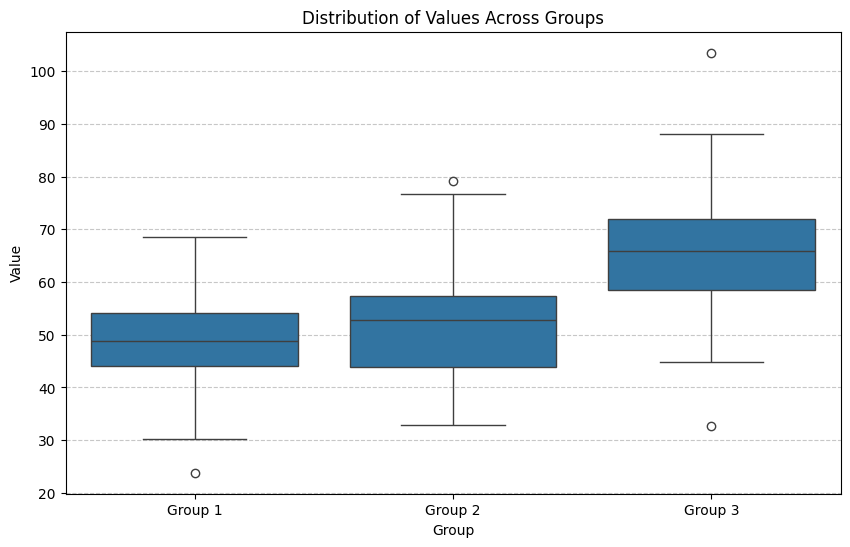

In [2]:
# Generate synthetic data for three groups
np.random.seed(42) # for reproducibility

group1_data = np.random.normal(loc=50, scale=10, size=100) # Mean 50, Std Dev 10
group2_data = np.random.normal(loc=52, scale=10, size=100) # Mean 52, Std Dev 10 (slightly different)
group3_data = np.random.normal(loc=65, scale=10, size=100) # Mean 65, Std Dev 10 (significantly different)

# Combine into a single DataFrame for easier processing
data = pd.DataFrame({
    'value': np.concatenate([group1_data, group2_data, group3_data]),
    'group': ['Group 1']*len(group1_data) + ['Group 2']*len(group2_data) + ['Group 3']*len(group3_data)
})

print("Descriptive statistics for each group:")
print(data.groupby('group')['value'].describe())

# Visualize the data distribution
plt.figure(figsize=(10, 6))
sns.boxplot(x='group', y='value', data=data)
plt.title('Distribution of Values Across Groups')
plt.xlabel('Group')
plt.ylabel('Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## One-Way ANOVA (Analysis of Variance)

ANOVA is a statistical test used to compare the means of three or more independent groups to determine if there are any statistically significant differences between them. The null hypothesis ($H_0$) for ANOVA is that the means of all groups are equal, and the alternative hypothesis ($H_1$) is that at least one group mean is different from the others.

Here, we use `scipy.stats.f_oneway` to perform the ANOVA test.

In [3]:
# Perform one-way ANOVA
f_statistic, p_value = stats.f_oneway(group1_data, group2_data, group3_data)

print(f"F-statistic: {f_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

F-statistic: 80.65
P-value: 0.000


### Interpretation of ANOVA Results

*   **F-statistic**: This is the test statistic for ANOVA. A larger F-statistic indicates more variation between group means relative to the variation within groups.
*   **P-value**: This tells us the probability of observing our data (or more extreme data) if the null hypothesis were true.

**If P-value < alpha (e.g., 0.05)**: We reject the null hypothesis. This suggests that there is a statistically significant difference between the means of at least two of the groups. However, ANOVA does not tell us *which* specific groups differ.

**If P-value >= alpha (e.g., 0.05)**: We fail to reject the null hypothesis. This suggests there is no statistically significant difference between the means of the groups.

In our case, with a p-value much smaller than 0.05, we reject the null hypothesis, indicating that there is a significant difference among the group means.

## Post-Hoc Tests (Multiple Comparisons)

Since ANOVA only tells us if *any* group means differ, but not *which* ones, we need to perform post-hoc tests. These tests are designed to make pairwise comparisons between groups while controlling for the increased risk of Type I errors (false positives) that arises when performing multiple comparisons.

One common post-hoc test is **Tukey's Honestly Significant Difference (HSD)**. Tukey's HSD test allows you to compare all possible pairs of means while maintaining a specified family-wise error rate.

### Comparison and Interpretation:

*   **Tukey's HSD**: Ideal for all-pairwise comparisons when you have three or more groups and want to maintain the family-wise error rate. It's generally more powerful for this specific scenario than Bonferroni.
*   **Bonferroni Correction**: A general-purpose, simple, but very conservative method. It's suitable when you have a small number of comparisons or when you absolutely need to minimize the chance of any false positives across *any* set of tests. In our example, it's quite strict.
*   **Holm-Bonferroni Method**: A more powerful (less conservative) alternative to the standard Bonferroni correction. It's a good general-purpose adjustment for multiple comparisons when you want to control the FWER. You'll often see that if a comparison is significant with Bonferroni, it will also be significant with Holm, and Holm might find significance for comparisons that Bonferroni misses due to its less stringent criteria.

Notice how the `reject` outcomes might differ slightly between these methods, reflecting their varying degrees of conservativeness. For our synthetic data, Group 1 vs. Group 2 often remains non-significant across most methods at $\alpha=0.05$, while comparisons involving Group 3 are consistently significant, which is consistent with our data generation.

## Other Common Post-Hoc Tests

While Tukey's HSD is popular for all-pairwise comparisons, other scenarios might call for different post-hoc tests or p-value adjustment methods. The primary goal of any post-hoc test is to control the **Family-Wise Error Rate (FWER)**, which is the probability of making at least one Type I error (false positive) across a set of multiple comparisons.

### Bonferroni Correction

**Context and Explanation**: The Bonferroni correction is one of the simplest and most conservative methods for adjusting p-values. It can be applied to any set of independent statistical tests. The core idea is to divide your desired alpha level (e.g., 0.05) by the number of comparisons being made. If you perform 'm' comparisons, your new significance level for each individual comparison becomes `alpha / m`.

*   **Pros**: Easy to understand and apply, widely applicable.
*   **Cons**: Very conservative, especially for a large number of comparisons. This means it has a high chance of leading to Type II errors (failing to detect a real effect). It is generally not recommended for all-pairwise comparisons when more powerful tests like Tukey's HSD are available and applicable.

**How it works**: For each individual p-value from your comparisons, you simply multiply it by the number of comparisons. If the adjusted p-value is still less than your original alpha, then the result is considered significant.

In [5]:
from statsmodels.stats.multitest import multipletests

# Extract group data
group_names = data['group'].unique()

# Perform pairwise t-tests and collect raw p-values
p_values_raw = []
comparisons = []

for i in range(len(group_names)):
    for j in range(i + 1, len(group_names)):
        group1 = group_names[i]
        group2 = group_names[j]

        data_g1 = data[data['group'] == group1]['value']
        data_g2 = data[data['group'] == group2]['value']

        # Perform independent t-test
        statistic, p_val = stats.ttest_ind(data_g1, data_g2)
        p_values_raw.append(p_val)
        comparisons.append(f"{group1} vs {group2}")

print("\n--- Pairwise T-test P-values (Raw) ---")
for comp, p_val in zip(comparisons, p_values_raw):
    print(f"{comp}: P-value = {p_val:.4f}")

# Apply Bonferroni correction
reject_bonferroni, p_values_bonferroni, _, _ = multipletests(p_values_raw, alpha=0.05, method='bonferroni')

print("\n--- Bonferroni Corrected P-values ---")
for comp, p_val, reject in zip(comparisons, p_values_bonferroni, reject_bonferroni):
    print(f"{comp}: Adjusted P-value = {p_val:.4f}, Reject H0 = {reject}")


--- Pairwise T-test P-values (Raw) ---
Group 1 vs Group 2: P-value = 0.0141
Group 1 vs Group 3: P-value = 0.0000
Group 2 vs Group 3: P-value = 0.0000

--- Bonferroni Corrected P-values ---
Group 1 vs Group 2: Adjusted P-value = 0.0423, Reject H0 = True
Group 1 vs Group 3: Adjusted P-value = 0.0000, Reject H0 = True
Group 2 vs Group 3: Adjusted P-value = 0.0000, Reject H0 = True


### Holm-Bonferroni Method (Holm's Method)

**Context and Explanation**: The Holm-Bonferroni method (often simply called Holm's method) is a sequentially rejective Bonferroni-type procedure that is less conservative than the standard Bonferroni correction while still controlling the Family-Wise Error Rate. It's generally preferred over the plain Bonferroni correction when multiple tests are performed.

**How it works**: Instead of applying a single, very strict alpha level to all tests, Holm's method orders the p-values from smallest to largest and compares each to a progressively larger alpha level. This sequential approach allows it to maintain the FWER control while being more powerful (less prone to Type II errors) than the standard Bonferroni correction.

**Procedure**:
1. Order the raw p-values from smallest to largest: $p_{(1)} \le p_{(2)} \le ... \le p_{(m)}$.
2. Compare $p_{(1)}$ to $\alpha / m$.
3. If $p_{(1)} \le \alpha / m$, then reject the null hypothesis for that comparison. Then, compare $p_{(2)}$ to $\alpha / (m-1)$.
4. If $p_{(2)} \le \alpha / (m-1)$, then reject the null hypothesis. Continue this process, comparing $p_{(k)}$ to $\alpha / (m-k+1)$.
5. Stop when you fail to reject a null hypothesis; all subsequent (larger) p-values are also considered non-significant.

In [6]:
# Apply Holm-Bonferroni correction
reject_holm, p_values_holm, _, _ = multipletests(p_values_raw, alpha=0.05, method='holm')

print("\n--- Holm-Bonferroni Corrected P-values ---")
for comp, p_val, reject in zip(comparisons, p_values_holm, reject_holm):
    print(f"{comp}: Adjusted P-value = {p_val:.4f}, Reject H0 = {reject}")


--- Holm-Bonferroni Corrected P-values ---
Group 1 vs Group 2: Adjusted P-value = 0.0141, Reject H0 = True
Group 1 vs Group 3: Adjusted P-value = 0.0000, Reject H0 = True
Group 2 vs Group 3: Adjusted P-value = 0.0000, Reject H0 = True


In [4]:
# Perform Tukey's HSD post-hoc test
tukey_result = pairwise_tukeyhsd(endog=data['value'], groups=data['group'], alpha=0.05)

print(tukey_result)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
Group 1 Group 2   3.2615 0.0518 -0.0193  6.5423  False
Group 1 Group 3  16.6874    0.0 13.4066 19.9683   True
Group 2 Group 3  13.4259    0.0 10.1451 16.7067   True
------------------------------------------------------


### Interpretation of Tukey's HSD Results

The output of Tukey's HSD provides:

*   **`group1` and `group2`**: The two groups being compared.
*   **`meandiff`**: The difference between the means of `group2` and `group1`.
*   **`p-adj`**: The adjusted p-value for the pairwise comparison. This p-value accounts for multiple comparisons.
*   **`lower` and `upper`**: The lower and upper bounds of the 95% confidence interval for the mean difference.
*   **`reject`**: A boolean value indicating whether the null hypothesis (that the means of the two groups are equal) is rejected at the specified alpha level (0.05 in this case).

**Based on the results:**

*   If `reject` is `True` for a pair, it means there is a statistically significant difference between the means of those two groups.
*   If `reject` is `False`, there is no statistically significant difference.

In our synthetic data example, we should observe that Group 1 vs. Group 3 and Group 2 vs. Group 3 show significant differences, while Group 1 vs. Group 2 might not, consistent with how we generated the data.